In [1]:
### Imports

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colormaps

%matplotlib inline 
mpl.rcParams['figure.dpi'] = 300

In [4]:
from sklearn.preprocessing import Normalizer

In [5]:
from chart_studio import plotly
import plotly.figure_factory as ff

In [6]:
pd.options.display.max_rows = 4000
pd.options.display.max_columns = 4000

In [7]:
DATA_VERSION = 'v5'

In [8]:
fig_dir = '../' + DATA_VERSION + '-fig/fig-time/'

In [9]:
gov_arch_csv = '../data/' + DATA_VERSION + '/communities_data_prepped.csv'

In [10]:
gov_df = pd.read_csv(gov_arch_csv)

In [28]:
gov_df.head()

,Name,Institutions,Mechanism,Notes,Time span,Geography,Size,Source,Metanotes,Heterogeneity,FC comments,expert check,Time span: Start,Time span: End,SCCS,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figure

In [30]:
list(gov_df)

['Name',
 'Institutions',
 'Mechanism',
 'Notes',
 'Time span',
 'Geography',
 'Size',
 'Source',
 'Metanotes',
 'Heterogeneity ',
 'FC comments',
 'expert check',
 'Time span: Start',
 'Time span: End',
 'SCCS',
 'is_SCCS',
 'decision_making_mechanisms_include_representation',
 'enforcement_mechanisms_include_paying_damages_compensation',
 'decision_making_mechanisms_include_temporary_position_of_power_term_limits',
 'enforcement_mechanisms_include_forced_labour',
 'decision_making_mechanisms_include_remunerated_position',
 'access_mechanisms_include_property_requirement',
 'access_mechanisms_include_induction_rite_ceremony',
 'access_mechanisms_include_gerontocracy',
 'decision_making_mechanisms_include_majority_voting',
 'enforcement_mechanisms_include_graduated_sanctions',
 'decision_making_mechanisms_include_plurality_voting',
 'enforcement_mechanisms_include_monitoring',
 'decision_making_mechanisms_include_assembly_local',
 'decision_making_mechanisms_include_petition',
 'access

In [12]:
## Timeline

In [13]:
size_dates_df = gov_df[['Time span: Start', 'Time span: End', 'Name', 'Size']]

In [14]:
size_dates_df

,Time span: Start,Time span: End,Name,Size
0,-200,0,Aedui (Celtic Oppida),"100,001 - 1,000,000"
1,1900,2023,Akha,"10,001 - 100,000"
2,300,1200,Amalfi,"10,001 - 100,000"
3,0,700,Arab nomads,Unknown
4,-1920,-1800,Assur,"1,001 - 10,000"
5,-508,-322,Athens (Classical Period),"100,001 - 1,000,000"
6,1100,1600,Aztec City-States,"100,001 - 1,000,000"
7,-900,-600,Babylonia,"10,001 - 100,000"
8,-400,-100,Carthage,"100,001 - 1,000,000"
9,900,1500,Central African communities,"10,001 - 100,000"


In [15]:
size_dates_df.describe()

,Time span: Start,Time span: End
count,91.000000,91.000000
mean,847.780220,1193.615385
std,1303.354448,1162.169951
min,-4100.000000,-3300.000000
25%,650.000000,1200.000000
50%,1450.000000,1800.000000
75%,1700.000000,1900.000000
max,1900.000000,2023.000000


In [16]:
size_categories = [
    '100 - 1,000',
    '1,001 - 10,000',
    '10,001 - 100,000',
    '100,001 - 1,000,000',
    '1,000,001 - 10,000,000',
    '10,000,000+',
    'Unknown'
]

In [17]:
df = size_dates_df

## Size x Time

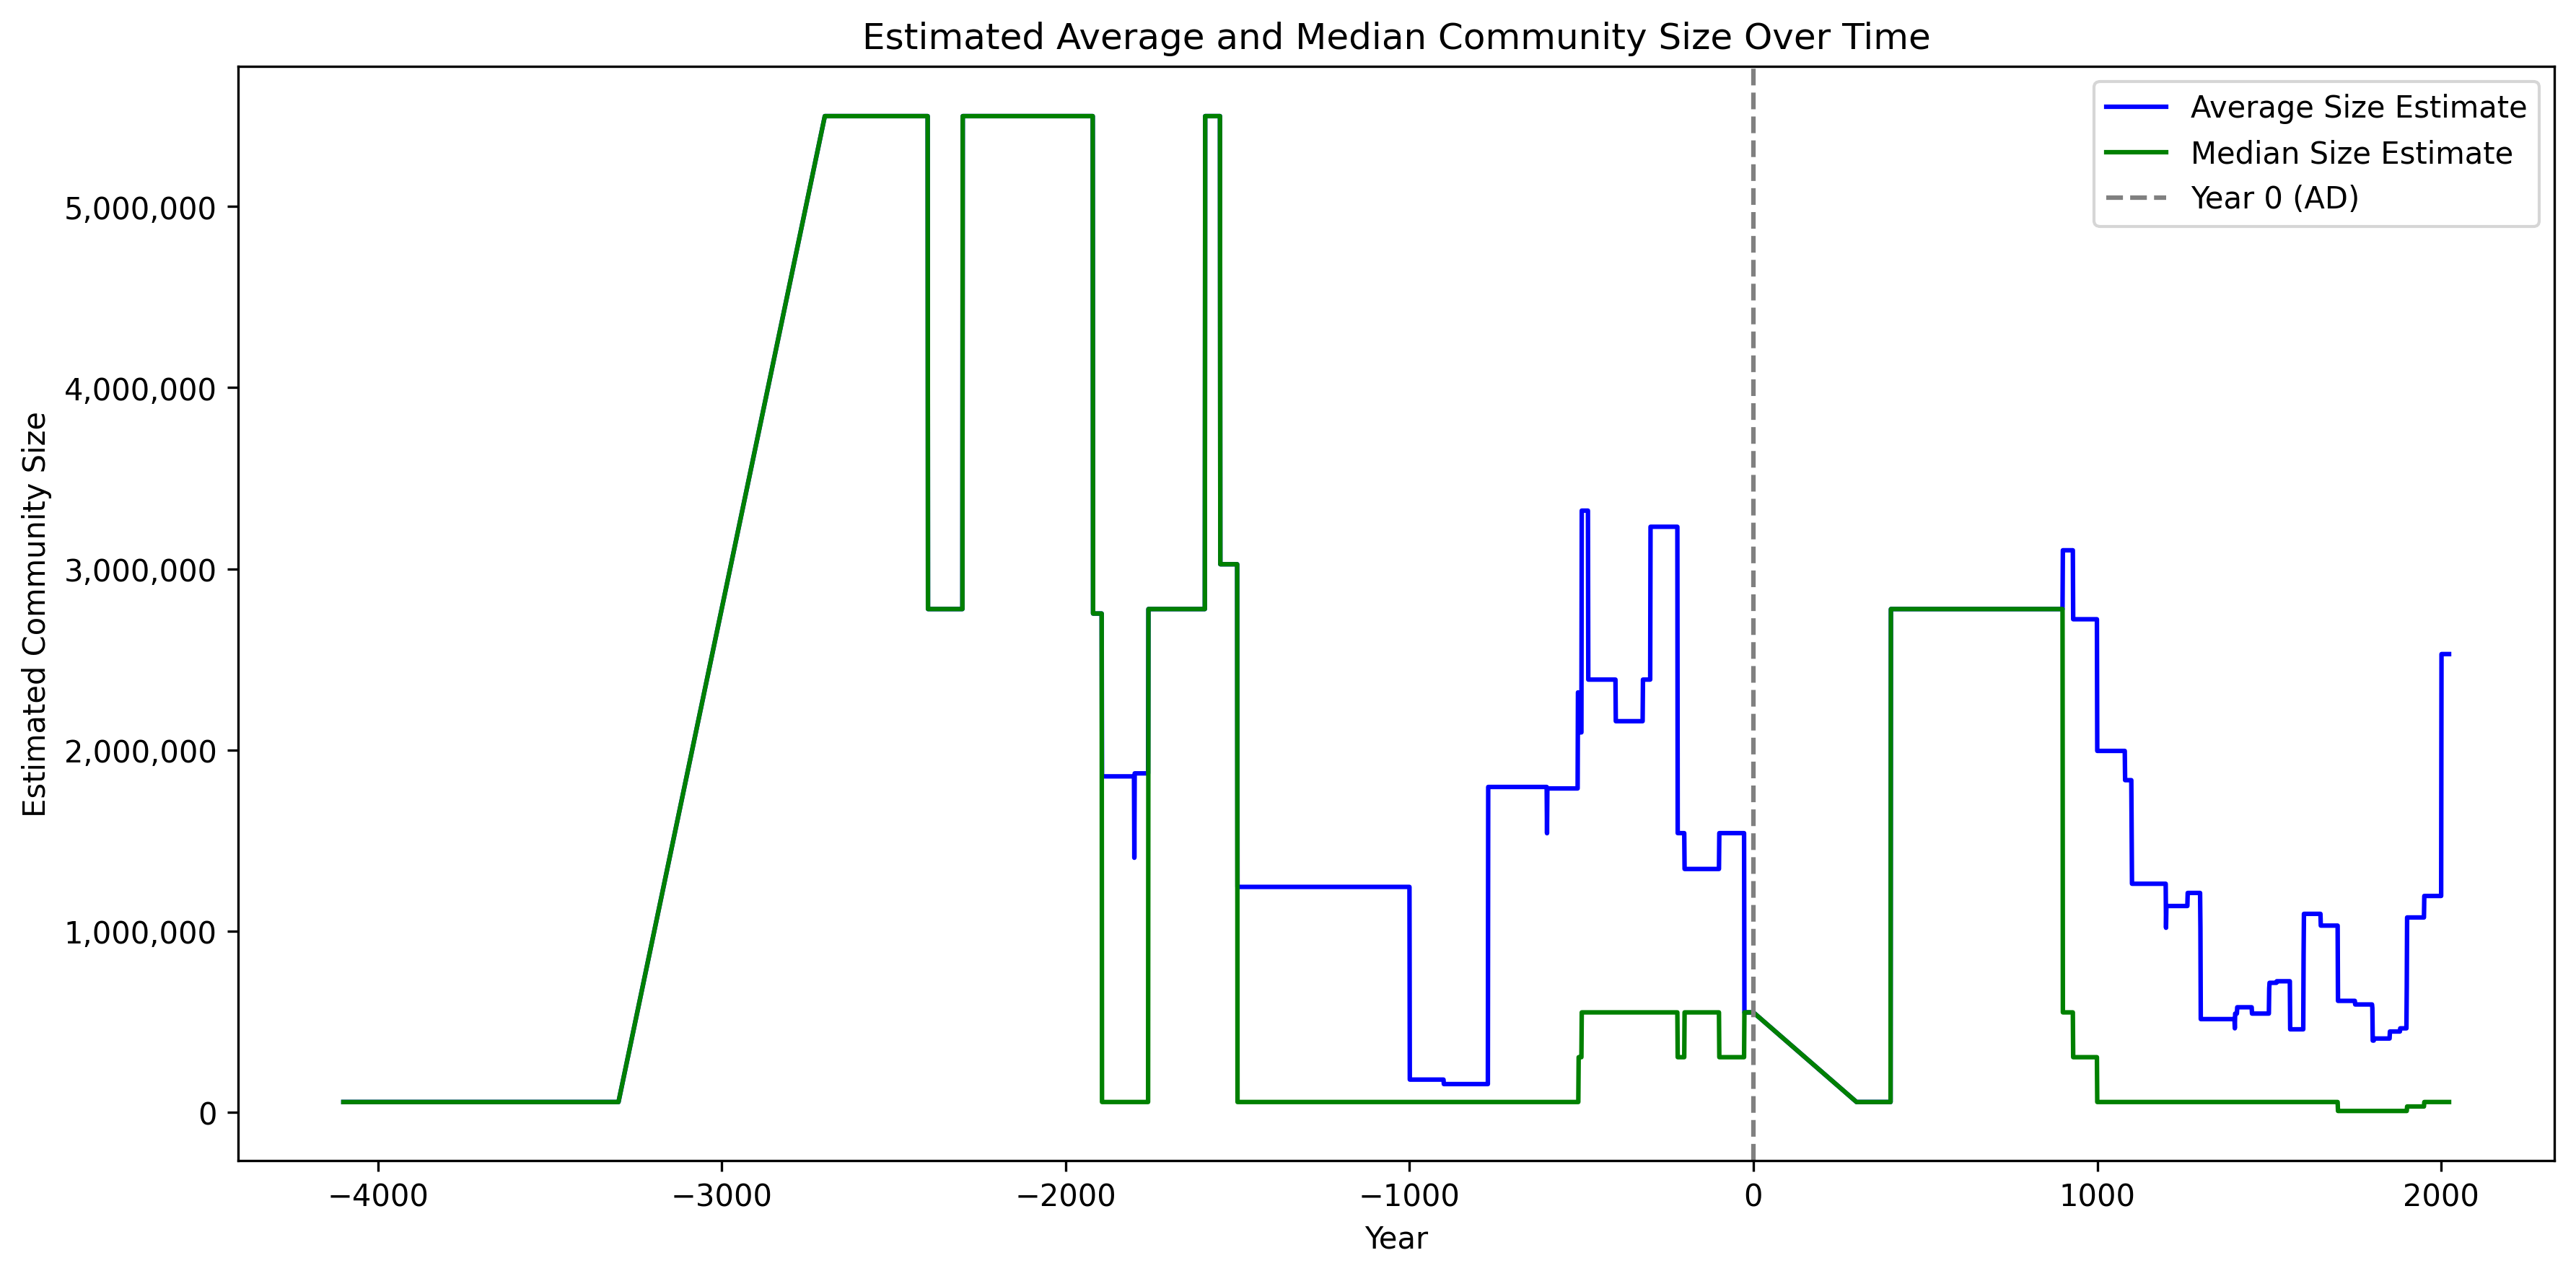

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Define mapping from categories to numeric estimates
size_map = {
    '100 - 1,000': 500,
    '1,001 - 10,000': 5500,
    '10,001 - 100,000': 55000,
    '100,001 - 1,000,000': 550000,
    '1,000,001 - 10,000,000': 5_500_000,
    '10,000,000+': 10_000_000,
    'Unknown': np.nan  # or assign a guess like 0 or median size
}

df['SizeNumeric'] = df['Size'].map(size_map)

# Step 2: Expand into timeline
records = []
for _, row in df.dropna(subset=['SizeNumeric']).iterrows():  # Drop unknowns for now
    for year in range(row['Time span: Start'], row['Time span: End'] + 1):
        records.append({'year': year, 'SizeNumeric': row['SizeNumeric'], 'Name': row['Name']})

timeline_df = pd.DataFrame(records)

# Step 3: Aggregate
agg_stats = timeline_df.groupby('year')['SizeNumeric'].agg(['mean', 'median']).reset_index()

# Step 4: Plot with better y-axis formatting
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 6))
plt.plot(agg_stats['year'], agg_stats['mean'], label='Average Size Estimate', color='blue')
plt.plot(agg_stats['year'], agg_stats['median'], label='Median Size Estimate', color='green')
plt.axvline(0, color='gray', linestyle='--', label='Year 0 (AD)')
plt.xlabel('Year')
plt.ylabel('Estimated Community Size')
plt.title('Estimated Average and Median Community Size Over Time')

# Format y-axis with commas (e.g., 1,000,000 instead of 1e6 or 0–5)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.legend()
plt.tight_layout()
plt.show()


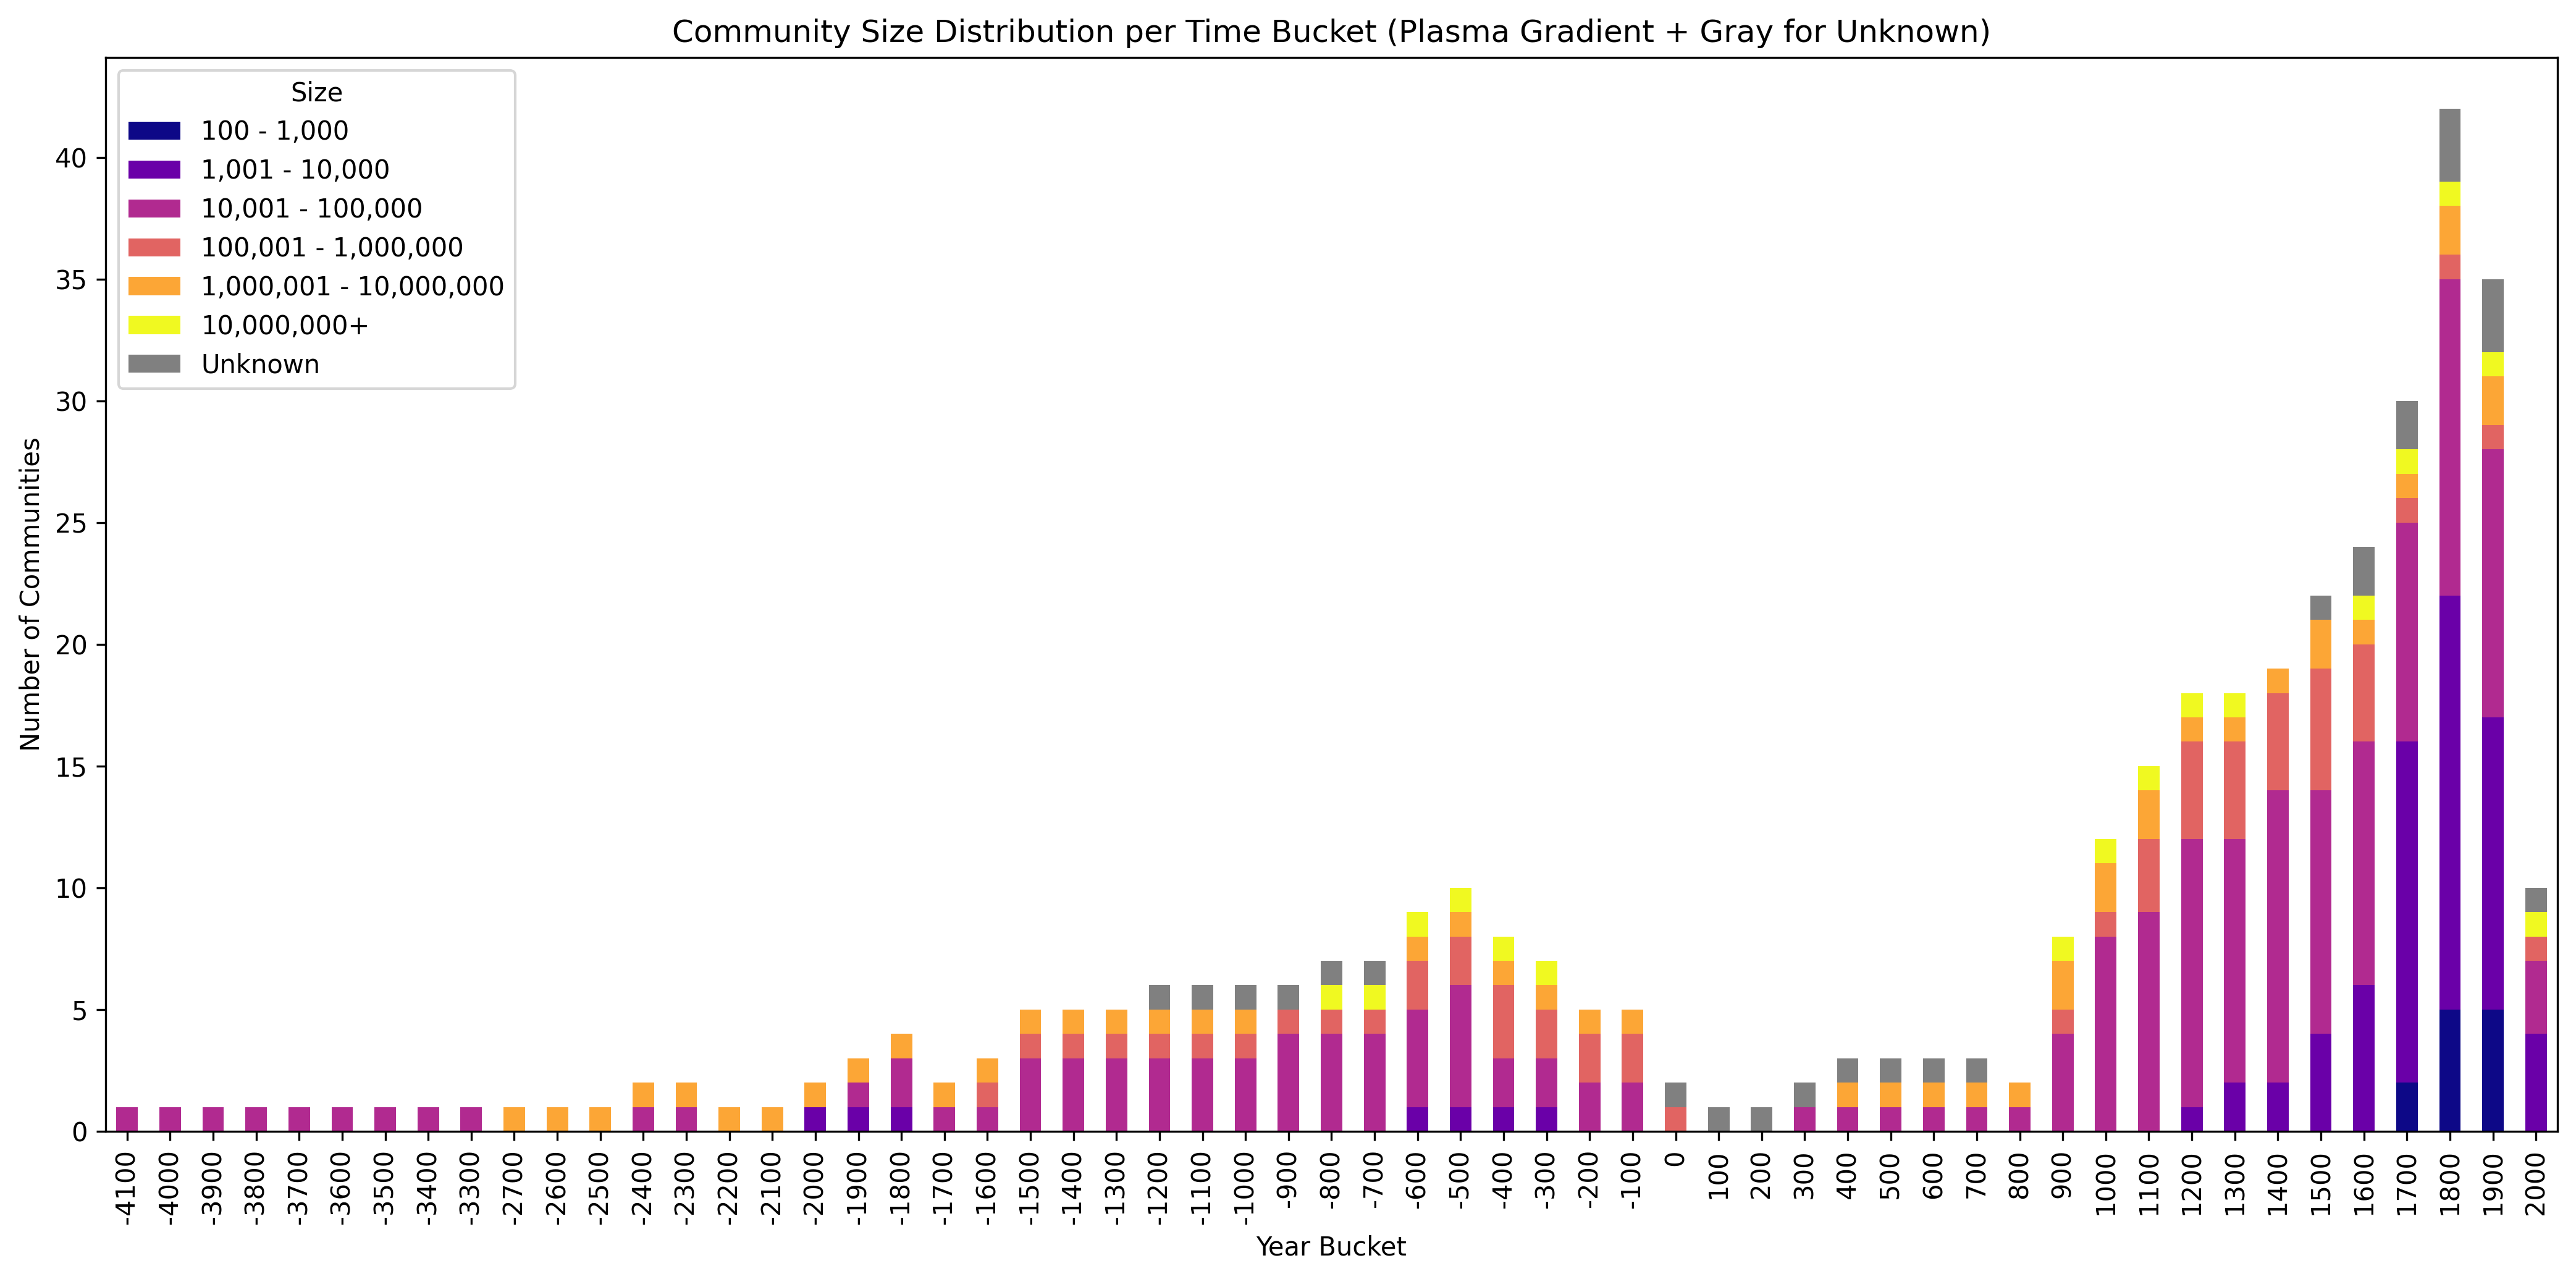

In [35]:
# Set Size as a categorical column with the defined order
df['Size'] = pd.Categorical(df['Size'], categories=size_categories, ordered=True)

# Assign each year to a 100-year bucket
def year_bucket(year, step=100):
    return int(np.floor(year / step) * step)

###

# Expand each community’s timespan into yearly records and assign year buckets
records = []
for _, row in df.iterrows():
    for year in range(row['Time span: Start'], row['Time span: End'] + 1):
        record = {
            'Name': row['Name'],  # uniquely identifies a community
            'year': year,
            'year_bucket': year_bucket(year),
            'Size': row['Size']
        }
        records.append(record)

binned_df = pd.DataFrame(records)

# 🧹 Drop duplicates so each community is counted once per time bucket
binned_df = binned_df.drop_duplicates(subset=['Name', 'year_bucket'])

###

# Count number of communities per size category per year bucket
hist_data = binned_df.groupby(by=['year_bucket', 'Size']).size().unstack(fill_value=0).reindex(columns=size_categories)

# Create plasma color gradient for known sizes only (exclude 'Unknown')
known_sizes = [s for s in size_categories if s != 'Unknown']
n_known = len(known_sizes)

# Generate plasma colors and add gray for 'Unknown'
plasma_cmap = colormaps['plasma'].resampled(n_known)
plasma_colors = [plasma_cmap(i) for i in range(n_known)]
color_list = plasma_colors + ['gray']  # Add gray for 'Unknown'

# Map each size category to its color
plasma_color_map = dict(zip(size_categories, color_list))

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
hist_data.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[plasma_color_map[cat] for cat in hist_data.columns]
)

ax.set_xlabel('Year Bucket')
ax.set_ylabel('Number of Communities')
ax.set_title('Community Size Distribution per Time Bucket (Plasma Gradient + Gray for Unknown)')

plt.tight_layout()
plt.savefig('../' + DATA_VERSION + '-fig/fig-time/size_time.png')
plt.show()

## Mechanisms x Time

In [20]:
df = gov_df

In [21]:
df.describe()

,Time span: Start,Time span: End,is_SCCS,decision_making_mechanisms_include_representation,enforcement_mechanisms_include_paying_damages_compensation,decision_making_mechanisms_include_temporary_position_of_power_term_limits,enforcement_mechanisms_include_forced_labour,decision_making_mechanisms_include_remunerated_position,access_mechanisms_include_property_requirement,access_mechanisms_include_induction_rite_ceremony,access_mechanisms_include_gerontocracy,decision_making_mechanisms_include_majority_voting,enforcement_mechanisms_include_graduated_sanctions,decision_making_mechanisms_include_plurality_voting,enforcement_mechanisms_include_monitoring,decision_making_mechanisms_include_assembly_local,decision_making_mechanisms_include_petition,access_mechanisms_include_enfranchisement,access_mechanisms_include_age_boundaries,enforcement_mechanisms_include_exit,decision_making_mechanisms_include_secret_ballot,decision_making_mechanisms_include_coalition,access_mechanisms_include_screening_process,decision_making_mechanisms_include_checks_and_balances,decision_making_mechanisms_include_consensus,decision_making_mechanisms_include_balance_of_power,enforcement_mechanisms_include_self-help,decision_making_mechanisms_include_ratification_acclamation_only,enforcement_mechanisms_include_civil_disobedience,enforcement_mechanisms_include_criticism_mocking_joking,decision_making_mechanisms_include_bureaucracy,access_mechanisms_include_meritocracy,decision_making_mechanisms_include_consent,enforcement_mechanisms_include_appeal,enforcement_mechanisms_include_litigation,decision_making_mechanisms_include_quorum,enforcement_mechanisms_include_reputational_risk,decision_making_mechanisms_include_agenda_setting,enforcement_mechanisms_include_mediation,decision_making_mechanisms_include_magistrate_official,decision_making_mechanisms_include_confederacy,decision_making_mechanisms_include_delegation,access_mechanisms_include_matriarchy,decision_making_mechanisms_include_council_central_,decision_making_mechanisms_include_dual-sex_political_system,enforcement_mechanisms_include_judicial_review,enforcement_mechanisms_include_scrutiny_of_officials,decision_making_mechanisms_include_word_of_mouth,decision_making_mechanisms_include_consultation,decision_making_mechanisms_include_mandate,decision_making_mechanisms_include_vote_by_proxy,access_mechanisms_include_heredity,access_mechanisms_include_co-optation,enforcement_mechanisms_include_arbitration,access_mechanisms_include_payment_for_occupying_office,access_mechanisms_include_dreaming,enforcement_mechanisms_include_negotiation,decision_making_mechanisms_include_vote_by_show_of_hands,decision_making_mechanisms_include_frequent_and_or_regular_meetings,decision_making_mechanisms_include_assembly_central,decision_making_mechanisms_include_rule_of_law,access_mechanisms_include_matrilineality,access_mechanisms_include_patronage_for_office,decision_making_mechanisms_include_unanimity,enforcement_mechanisms_include_fines,decision_making_mechanisms_include_supermajority,access_mechanisms_include_blood_relations,decision_making_mechanisms_include_council_local,access_mechanisms_include_lottery_random_selection,decision_making_mechanisms_include_veto,decision_making_mechanisms_include_lobbying,enforcement_mechanisms_include_capital_punishment,decision_making_mechanisms_include_turnover_rotation,decision_making_mechanisms_include_autocratic_leader_chief_bound,enforcement_mechanisms_include_jury_judge,decision_making_mechanisms_include_gathering,enforcement_mechanisms_include_suspension_expulsion_ostracism_proscription,enforcement_mechanisms_include_corporal_punishment_violence_against_perpetrator,enforcement_mechanisms_include_destruction_of_property,enforcement_mechanisms_include_tribunal_court_,access_mechanisms_include_open_political_unit,decision_making_mechanisms_include_kingchief-as-figurehead,access_mechanisms_include_popularity_,enforcement_mechanisms_include_seizing_of_property,access_mechanisms_include_

In [22]:
# Detect all mechanism columns
mechanism_cols = [col for col in df.columns if '_mechanisms_include_' in col]

# Split into groups
access_mechanisms = [col for col in mechanism_cols if col.startswith('access_')]
decision_mechanisms = [col for col in mechanism_cols if col.startswith('decision_making_')]
enforcement_mechanisms = [col for col in mechanism_cols if col.startswith('enforcement_')]
mechanisms = access_mechanisms + decision_mechanisms + enforcement_mechanisms

In [27]:
# Label formatter
def format_mechanism_label(col_name):
    if col_name.startswith("access_mechanisms_include_"):
        label = col_name.replace("access_mechanisms_include_", "Access: ")
    elif col_name.startswith("decision_making_mechanisms_include_"):
        label = col_name.replace("decision_making_mechanisms_include_", "Decision: ")
    elif col_name.startswith("enforcement_mechanisms_include_"):
        label = col_name.replace("enforcement_mechanisms_include_", "Enforcement: ")
    else:
        label = col_name
    return label.replace("_", " ").strip().title()

# Plot group
def plot_mechanism_group(group_mechanisms, title, prefix):
    if not group_mechanisms:
        print(f"Skipping {title}: no mechanisms found.")
        return

    label_map = {m: format_mechanism_label(m) for m in group_mechanisms}
    data = agg_df.set_index('year_bucket')[group_mechanisms].rename(columns=label_map)

    plt.figure(figsize=(16, max(4, len(group_mechanisms) * 0.3)))
    sns.heatmap(
        data.T,
        cmap='plasma',
        cbar_kws={'label': 'Count of Communities'},
        linewidths=0.5,
        linecolor='gray',
        vmax=vmax
    )
    plt.title(title)
    plt.xlabel('Year Bucket')
    plt.ylabel('Mechanism')

    plt.tight_layout()
    plt.savefig('../' + DATA_VERSION + '-fig/fig-time/' + prefix + '_mechanisms_time.png')
    plt.show()


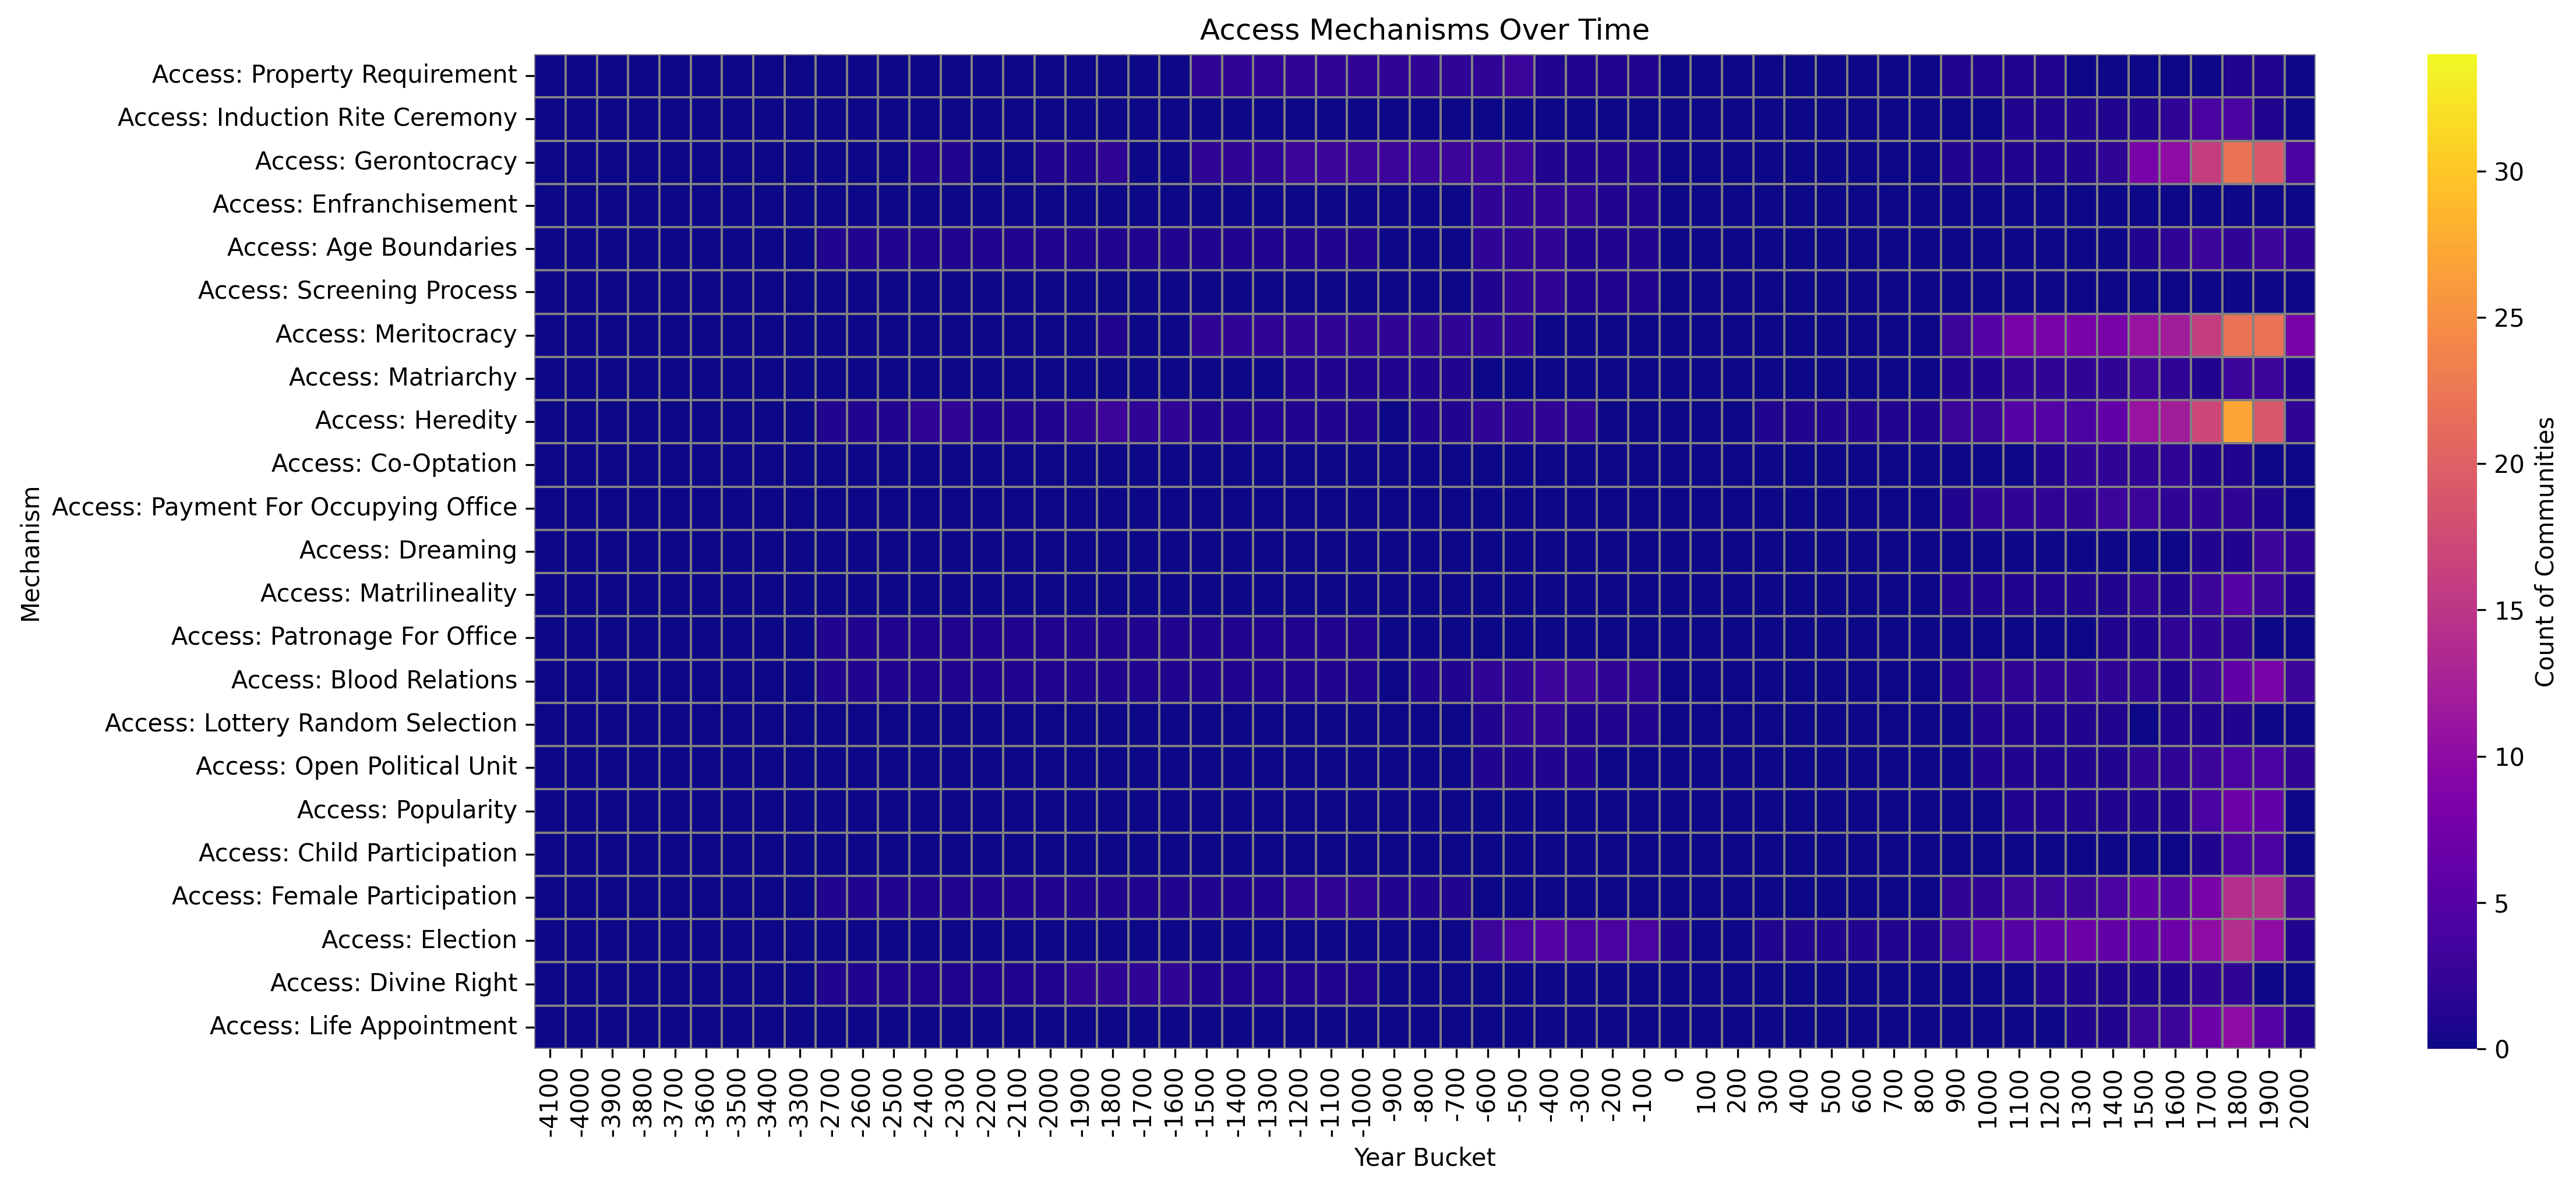

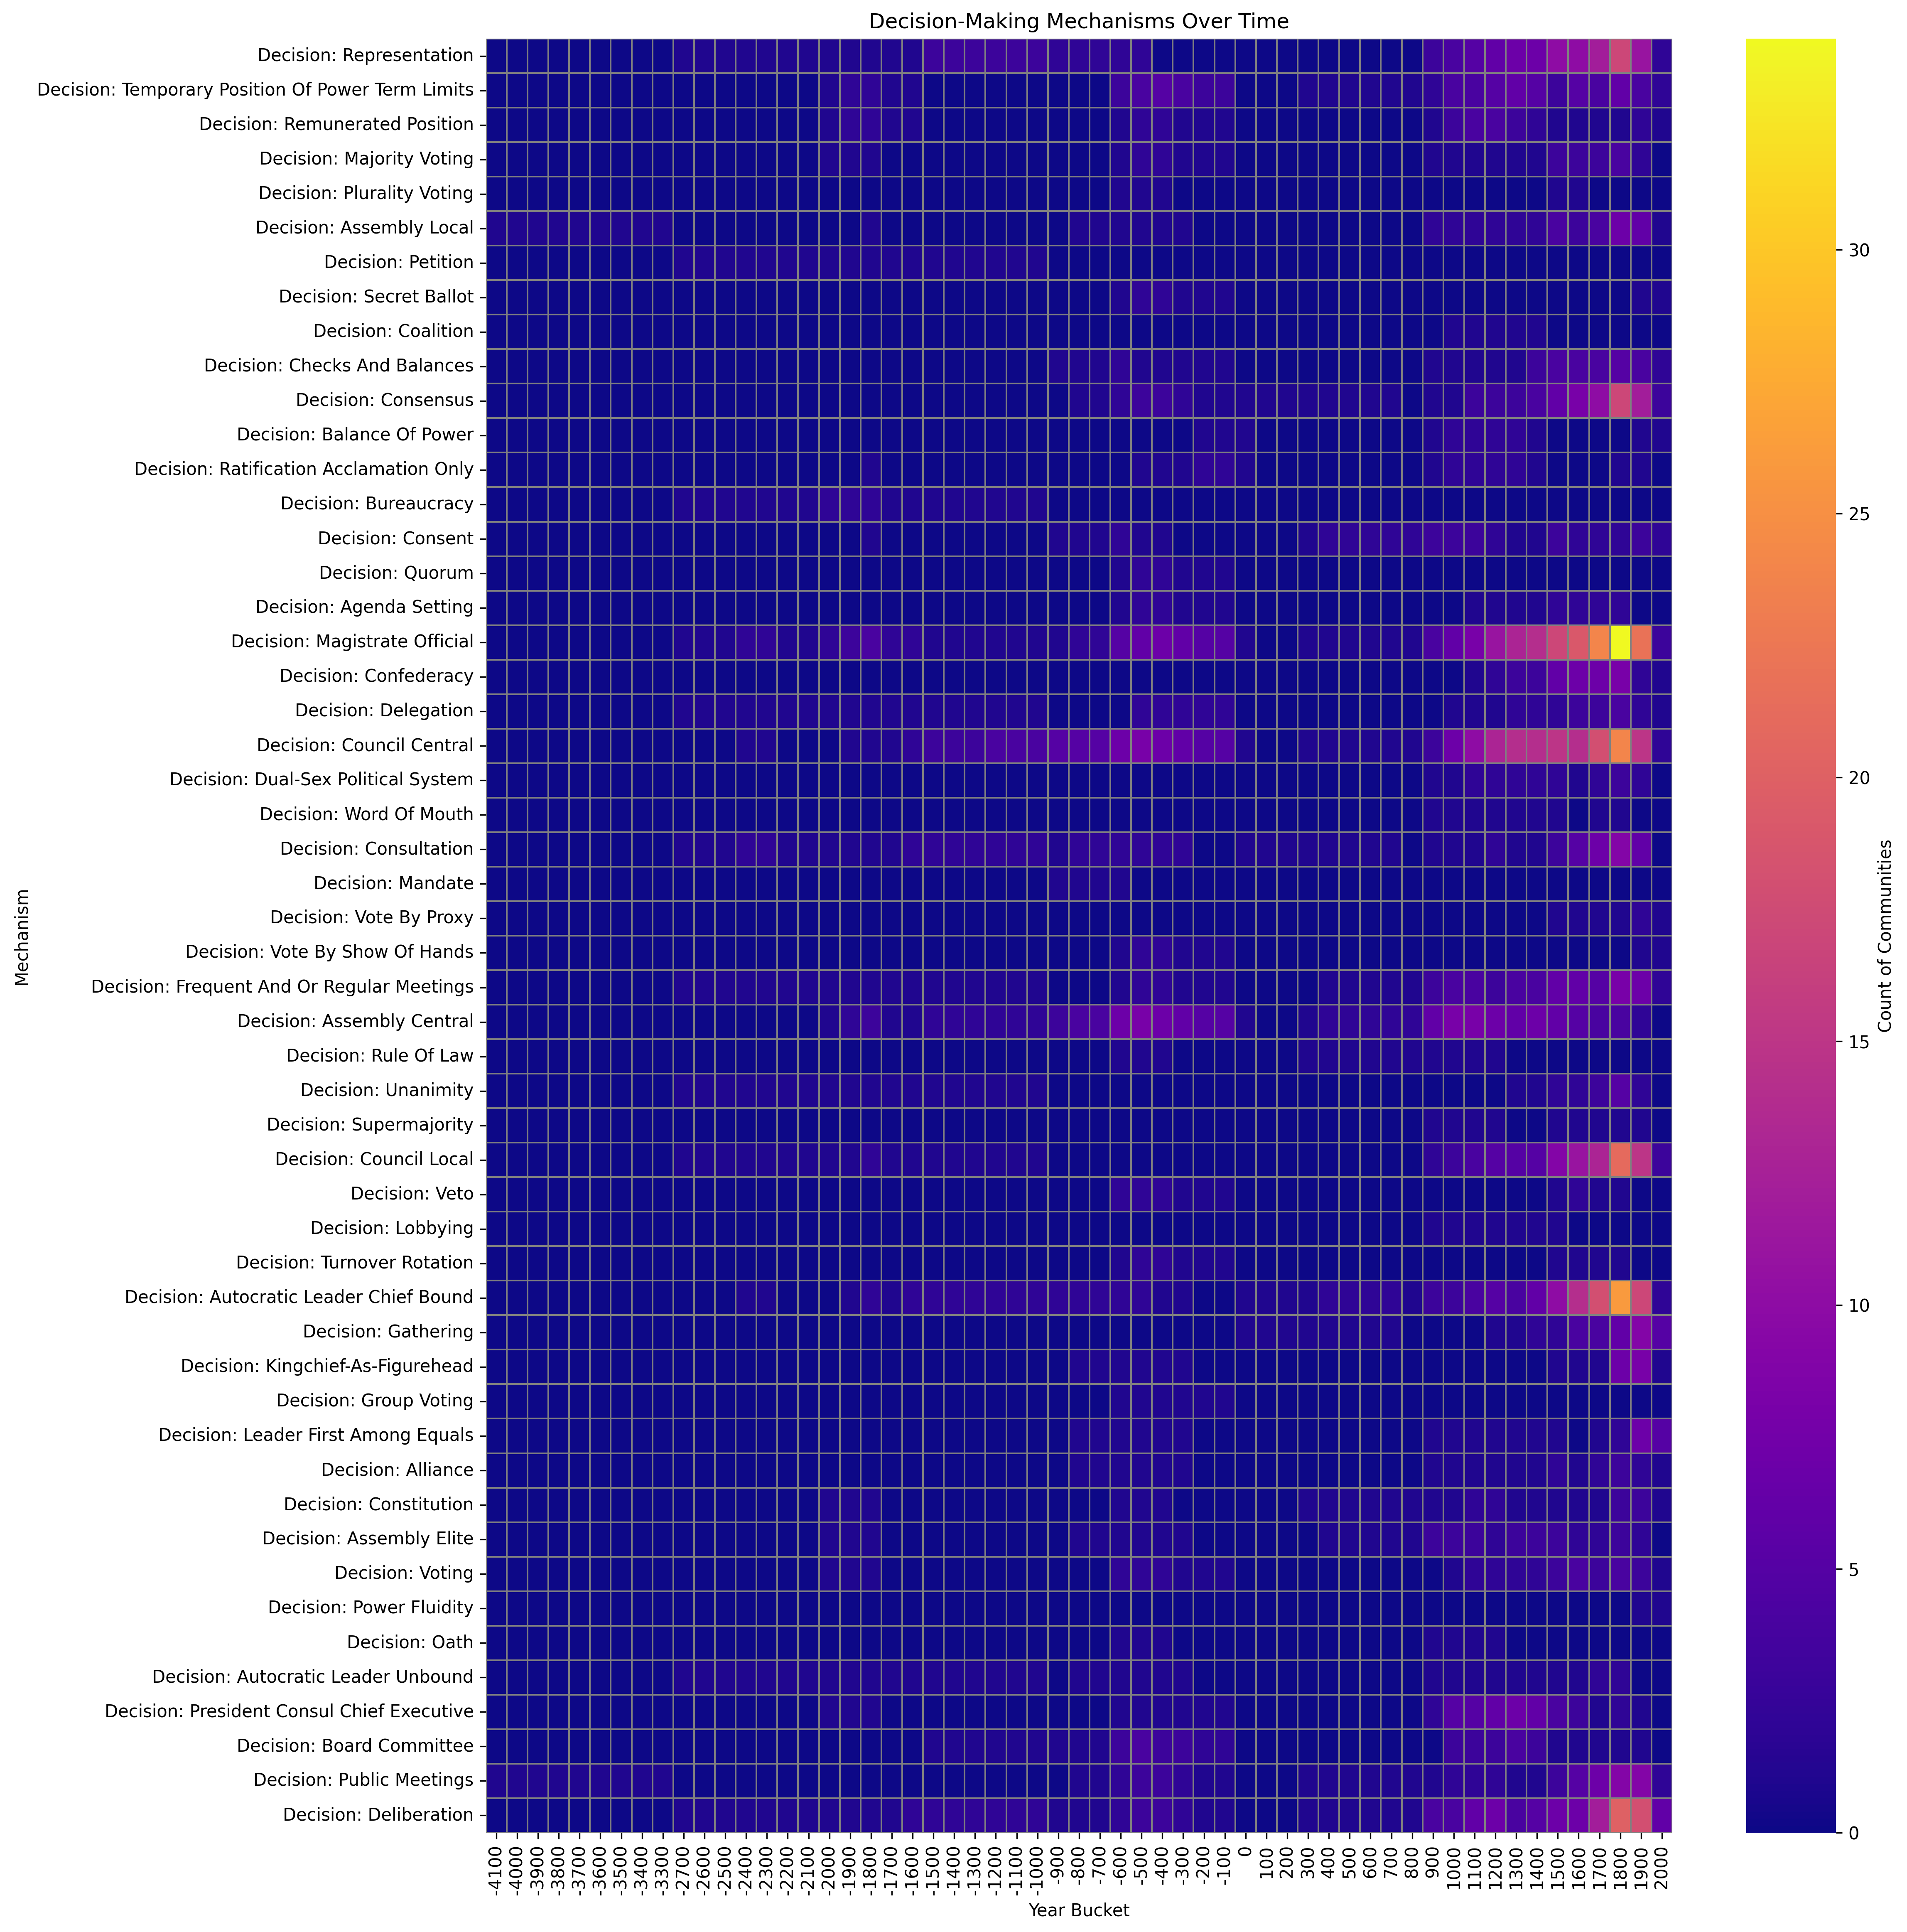

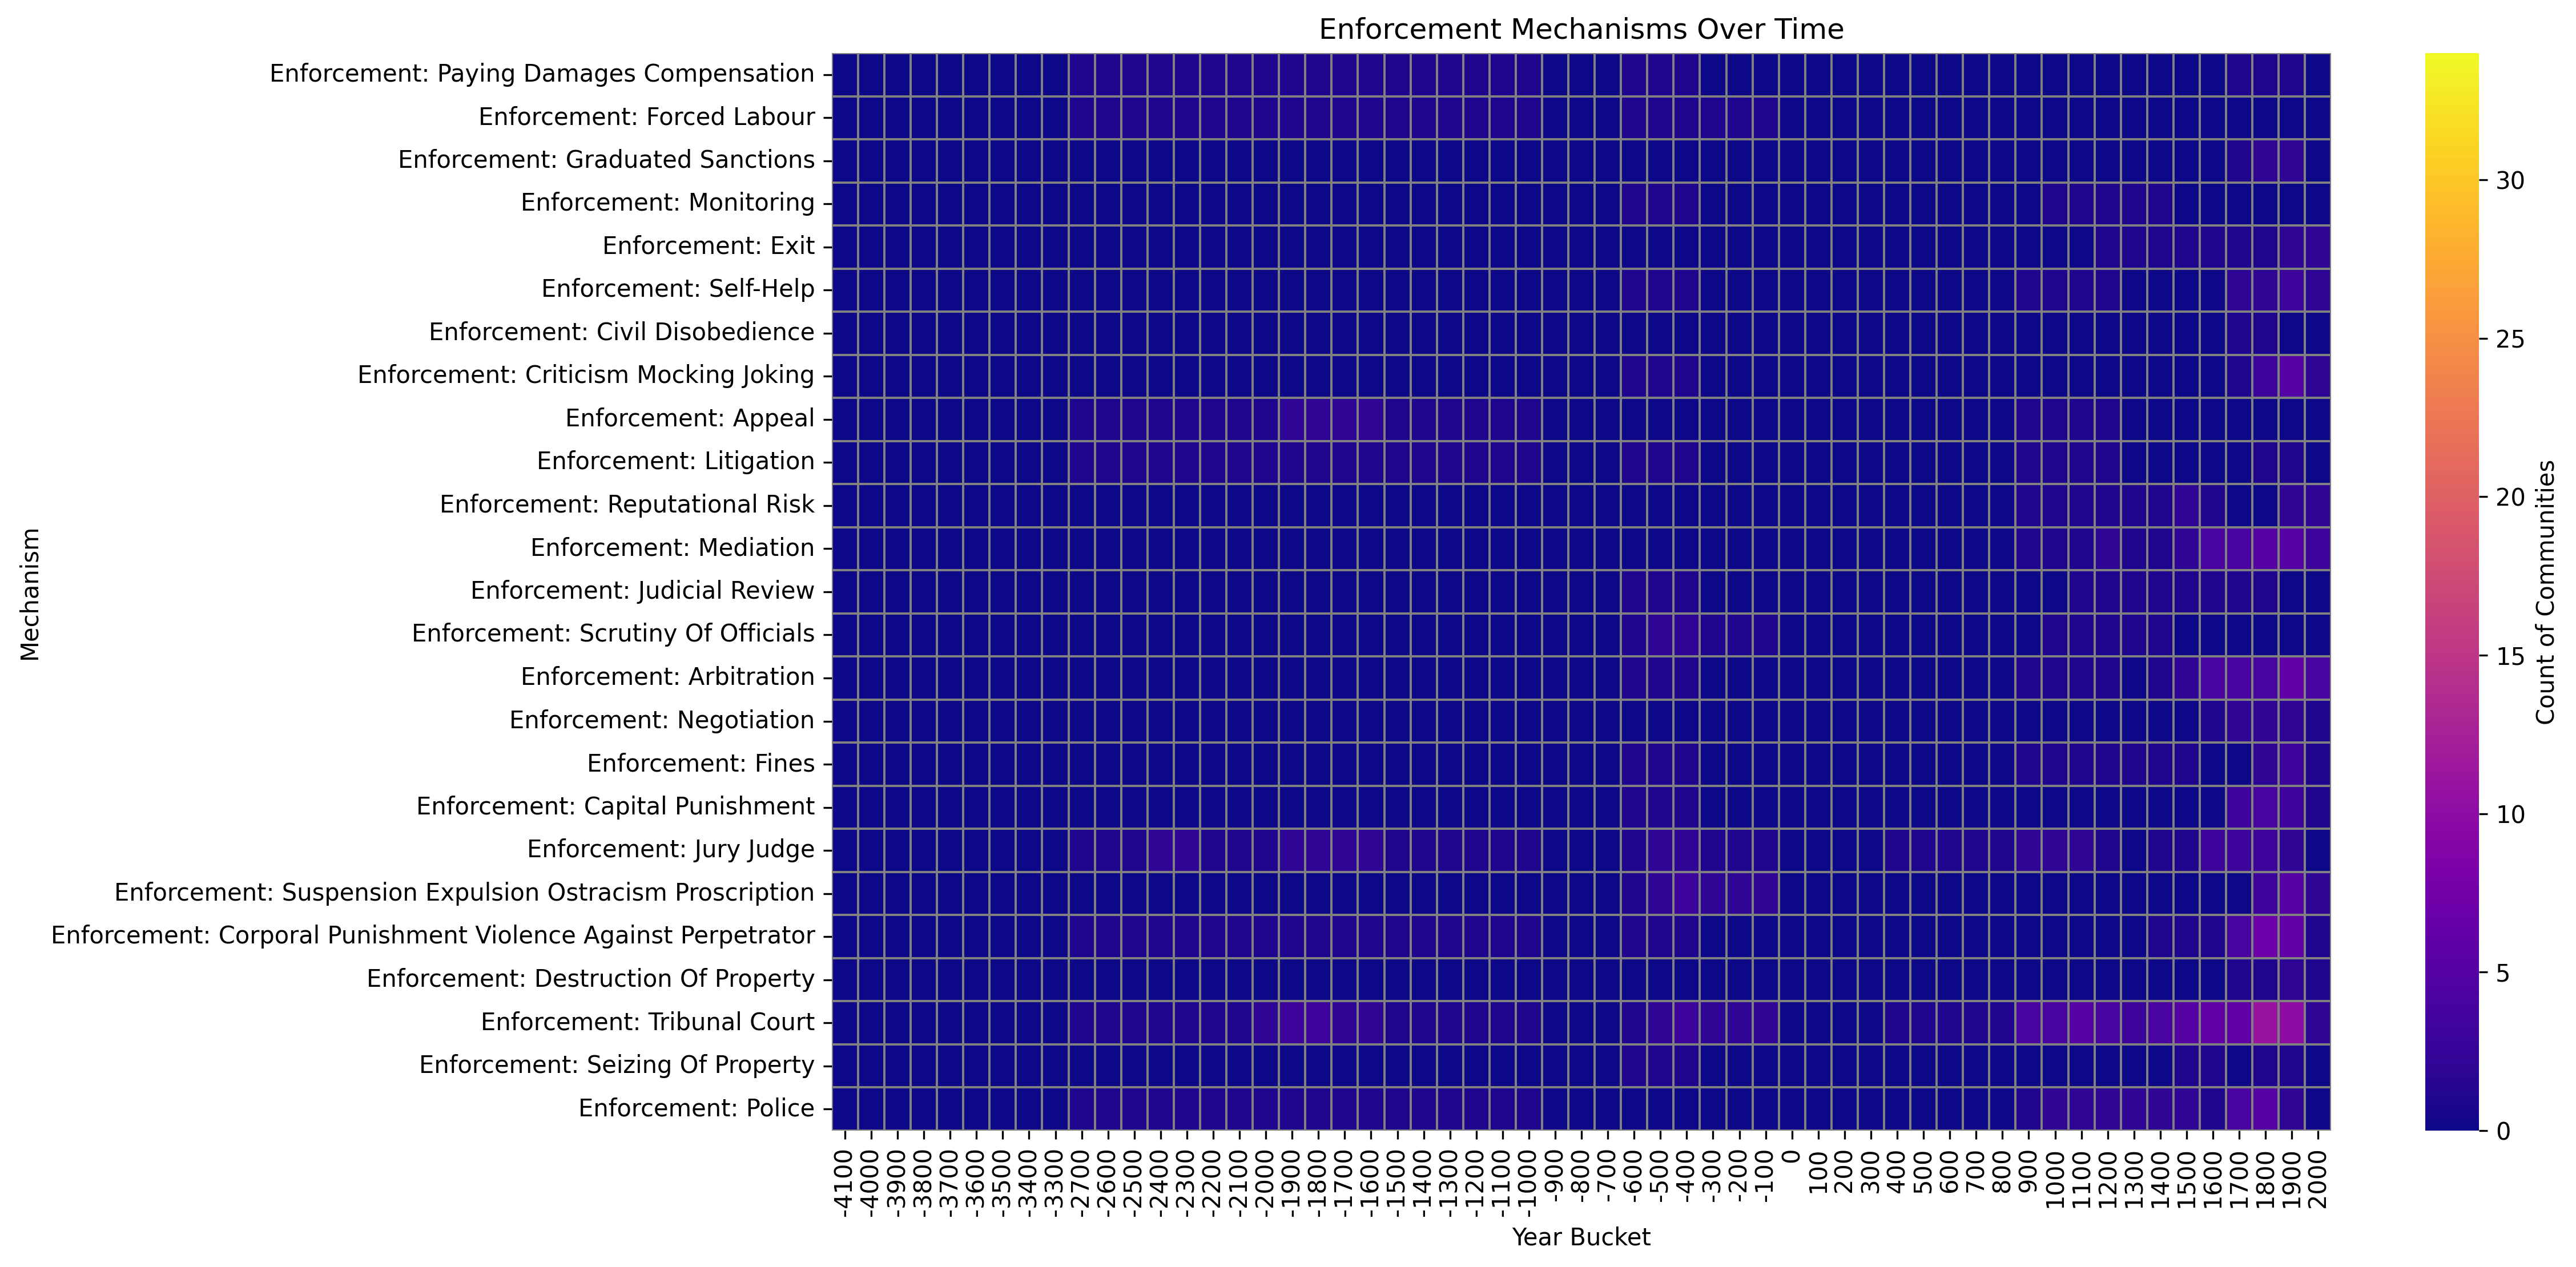

In [31]:
records = []
for _, row in df.iterrows():
    for year in range(row['Time span: Start'], row['Time span: End'] + 1):
        record = {
            'Name': row['Name'],  # uniquely identifies a community
            'year': year,
        }
        for m in mechanisms:
            record[m] = row[m]
        records.append(record)

timeline_df = pd.DataFrame(records)
timeline_df['year_bucket'] = (timeline_df['year'] // 100) * 100

# 🧹 Drop duplicates so each community is counted once per time bucket
timeline_df = timeline_df.drop_duplicates(subset=['Name', 'year_bucket'])

# Aggregate counts per time bucket
agg_df = timeline_df.groupby('year_bucket')[mechanisms].sum().reset_index()

# Shared color scale max
vmax_candidates = []
for group in [access_mechanisms, decision_mechanisms, enforcement_mechanisms]:
    if group:
        vmax_candidates.append(agg_df[group].to_numpy().max())
vmax = max(vmax_candidates) if vmax_candidates else None

# Plot each group
plot_mechanism_group(access_mechanisms, "Access Mechanisms Over Time", 'access')
plot_mechanism_group(decision_mechanisms, "Decision-Making Mechanisms Over Time", 'decision_making')
plot_mechanism_group(enforcement_mechanisms, "Enforcement Mechanisms Over Time", 'enforcement')

 ### Aggregate

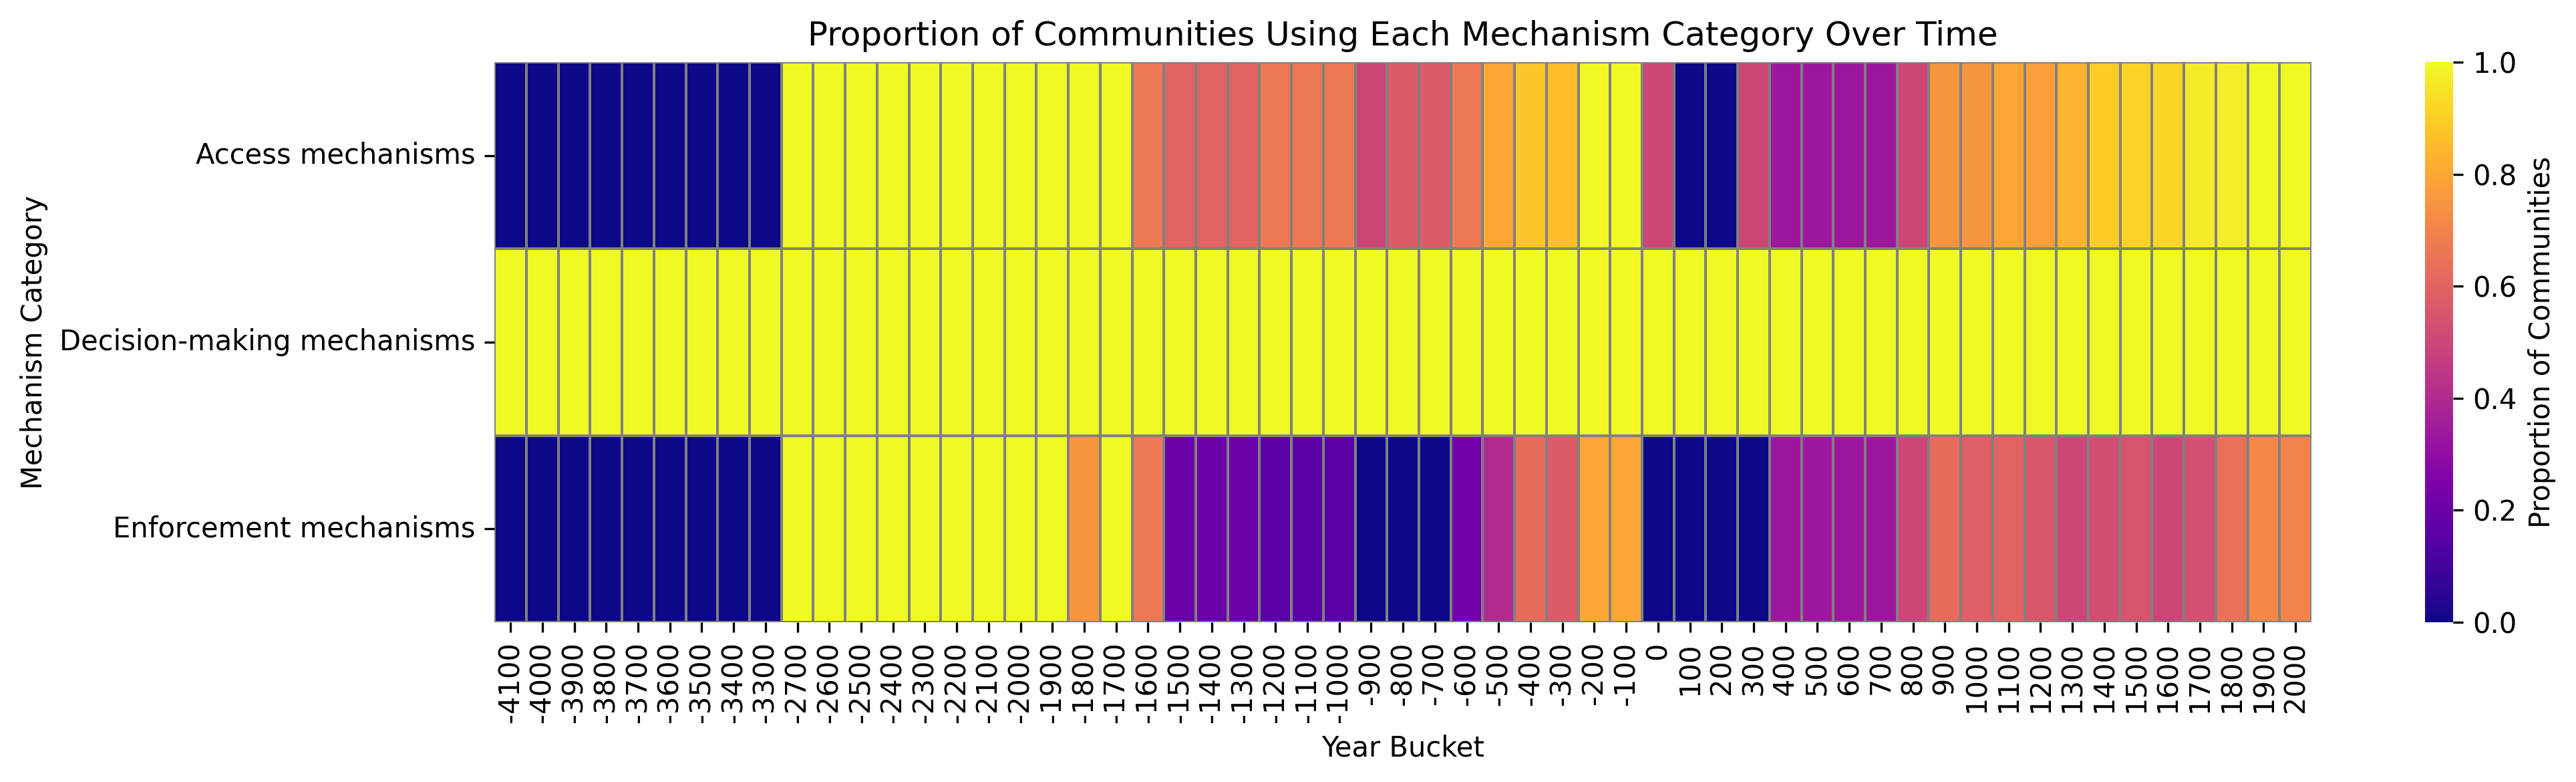

In [37]:
df['used_access'] = (df[access_mechanisms].sum(axis=1) > 0).astype(int)
df['used_decision'] = (df[decision_mechanisms].sum(axis=1) > 0).astype(int)
df['used_enforcement'] = (df[enforcement_mechanisms].sum(axis=1) > 0).astype(int)

# --- Step 3: Expand each community over its time span ---
records = []
for _, row in df.iterrows():
    for year in range(row['Time span: Start'], row['Time span: End'] + 1):
        records.append({
            'Name': row['Name'],  # uniquely identifies a community
            'year': year,
            'used_access': row['used_access'],
            'used_decision': row['used_decision'],
            'used_enforcement': row['used_enforcement']
        })

expanded_df = pd.DataFrame(records)
expanded_df['year_bucket'] = expanded_df['year'].apply(lambda y: int(np.floor(y / 100) * 100))

# 🧹 Drop duplicates so each community is counted once per time bucket
expanded_df = expanded_df.drop_duplicates(subset=['Name', 'year_bucket'])

# --- Step 4: Aggregate counts and normalize ---
# Total number of communities active per bucket
community_counts = expanded_df.groupby('year_bucket').size().rename('total_communities')

# Number of communities using each category per bucket
agg = expanded_df.groupby('year_bucket')[['used_access', 'used_decision', 'used_enforcement']].sum()

# Normalize by total communities per bucket
normalized = agg.div(community_counts, axis=0).reset_index()

# Rename columns for plotting
normalized = normalized.rename(columns={
    'used_access': 'Access mechanisms',
    'used_decision': 'Decision-making mechanisms',
    'used_enforcement': 'Enforcement mechanisms'
})

# --- Step 5: Format for heatmap ---
melted = normalized.melt(id_vars='year_bucket', var_name='category', value_name='proportion')
heatmap_data = melted.pivot(index='category', columns='year_bucket', values='proportion')

# --- Step 6: Plot ---
plt.figure(figsize=(14, 4))
sns.heatmap(
    heatmap_data,
    cmap='plasma',
    cbar_kws={'label': 'Proportion of Communities'},
    linewidths=0.5,
    linecolor='gray',
    vmin=0, vmax=1
)
plt.title('Proportion of Communities Using Each Mechanism Category Over Time')
plt.xlabel('Year Bucket')
plt.ylabel('Mechanism Category')

plt.tight_layout()
plt.savefig('../' + DATA_VERSION + '-fig/fig-time/mechanisms_time.png', bbox_inches='tight')
plt.show()

In [43]:
agg.sum()

used_access         328
used_decision       402
used_enforcement    204
dtype: int64

<Figure size 4200x1800 with 0 Axes>

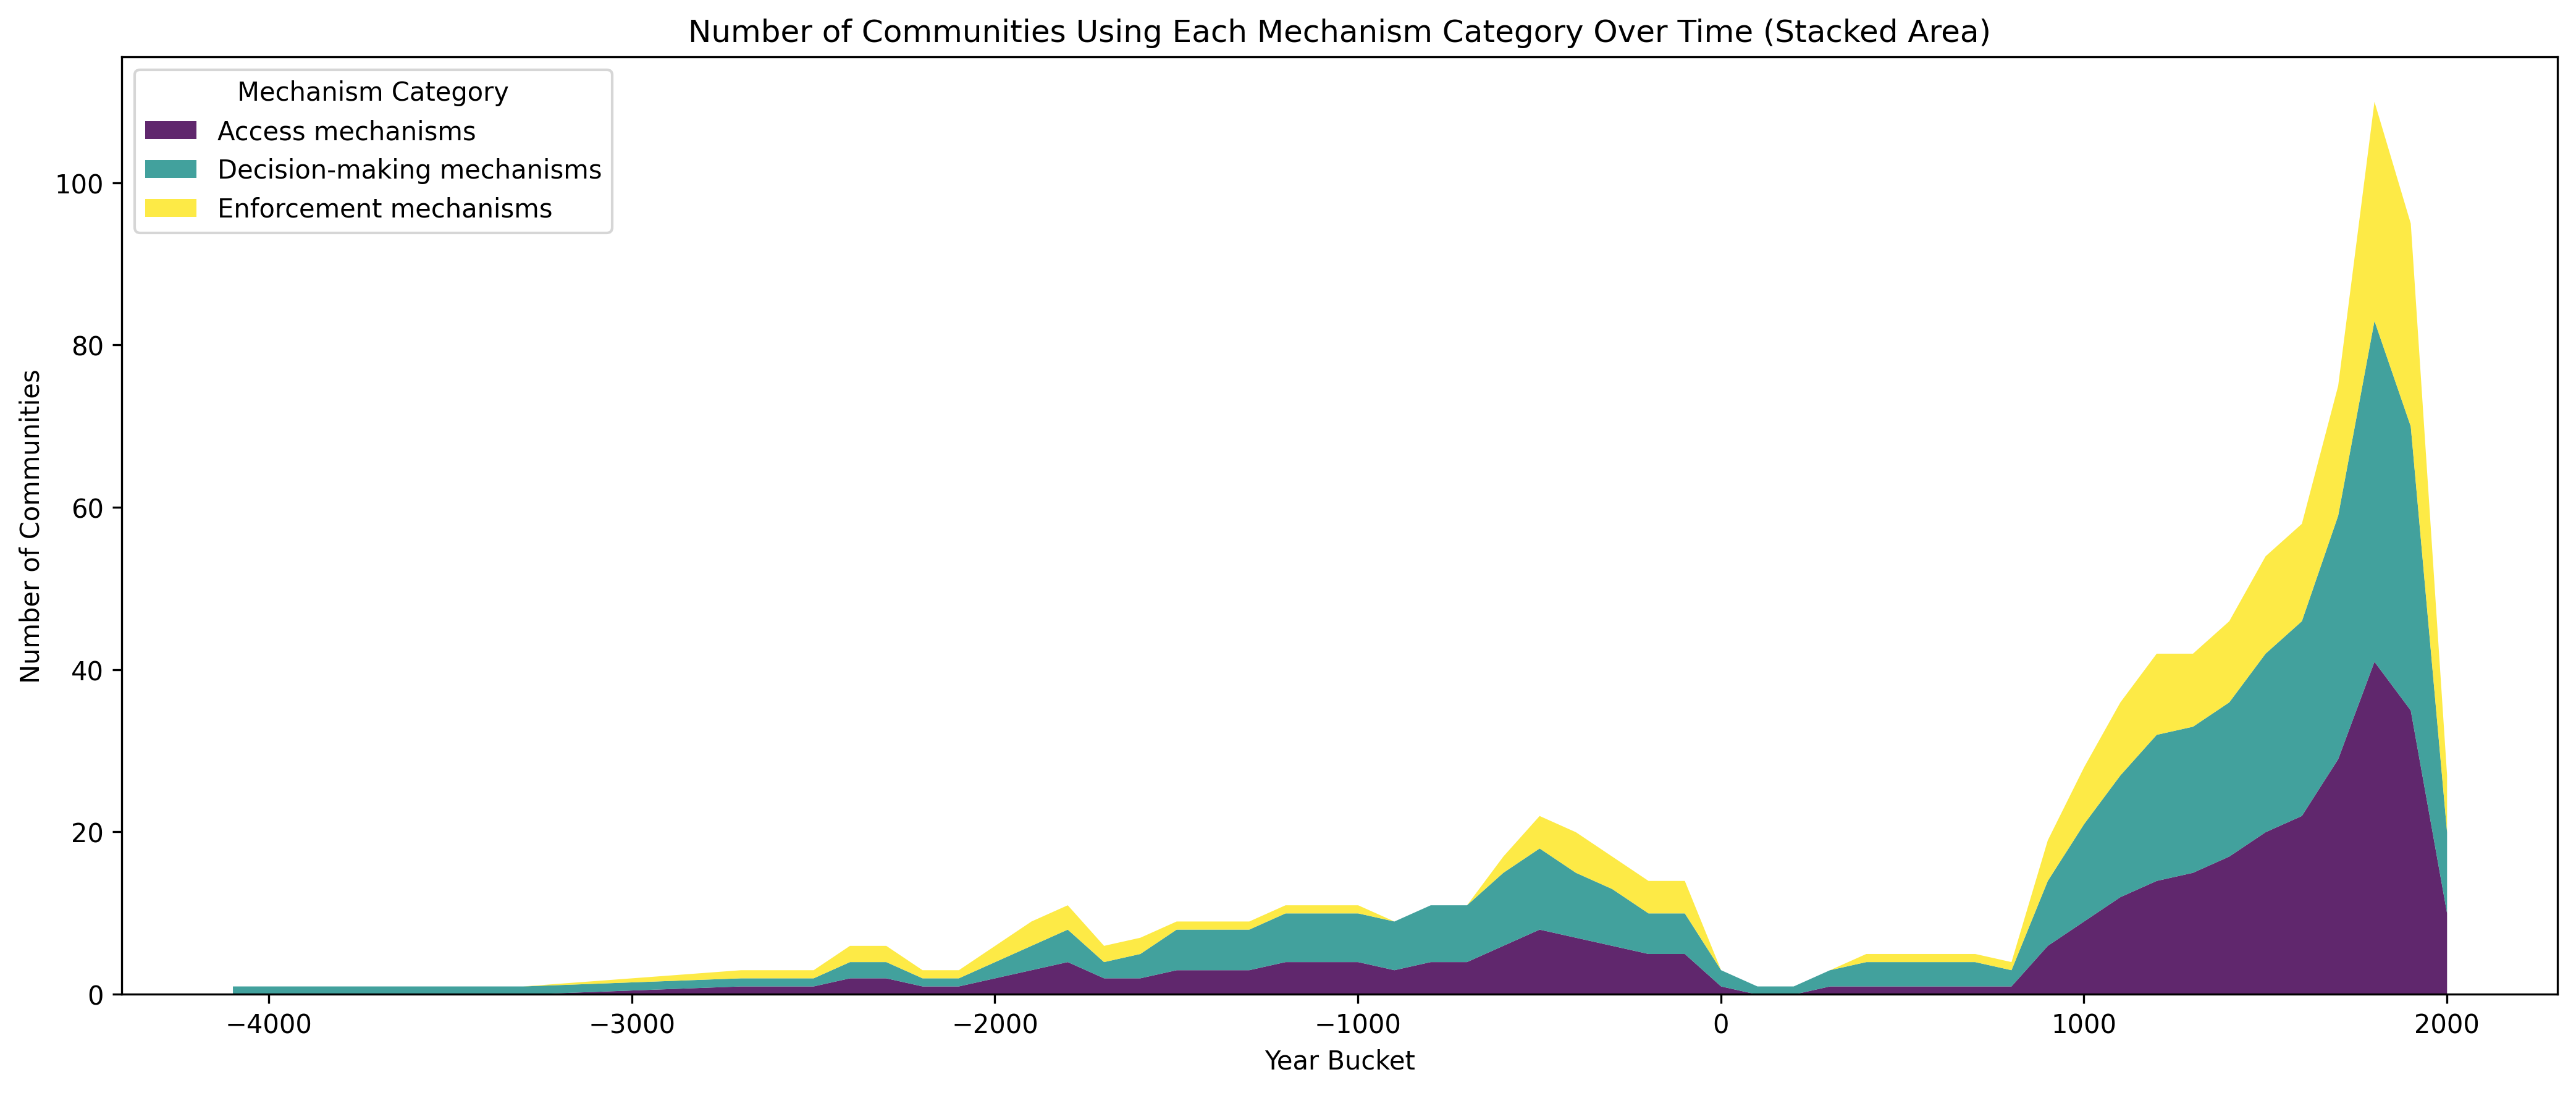

In [38]:
# Group by time bucket and sum the binary flags
raw_counts = expanded_df.groupby('year_bucket')[
    ['used_access', 'used_decision', 'used_enforcement']
].sum()

# Rename columns for prettier axis labels
raw_counts = raw_counts.rename(columns={
    'used_access': 'Access mechanisms',
    'used_decision': 'Decision-making mechanisms',
    'used_enforcement': 'Enforcement mechanisms'
})

# --- Step 2: Plot stacked area chart ---
plt.figure(figsize=(14, 6))
raw_counts.plot.area(
    stacked=True,
    cmap='viridis',
    alpha=0.85,
    linewidth=0,
    figsize=(14, 6)
)
plt.title('Number of Communities Using Each Mechanism Category Over Time (Stacked Area)')
plt.xlabel('Year Bucket')
plt.ylabel('Number of Communities')
plt.legend(title='Mechanism Category')

plt.savefig('../' + DATA_VERSION + '-fig/fig-time/mechanisms_time_area.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

In [46]:
raw_counts

,Access mechanisms,Decision-making mechanisms,Enforcement mechanisms
year_bucket,,,
-4100,0,1,0
-4000,0,1,0
-3900,0,1,0
-3800,0,1,0
-3700,0,1,0
-3600,0,1,0
-3500,0,1,0
-3400,0,1,0
-3300,0,1,0


<Figure size 4200x1800 with 0 Axes>

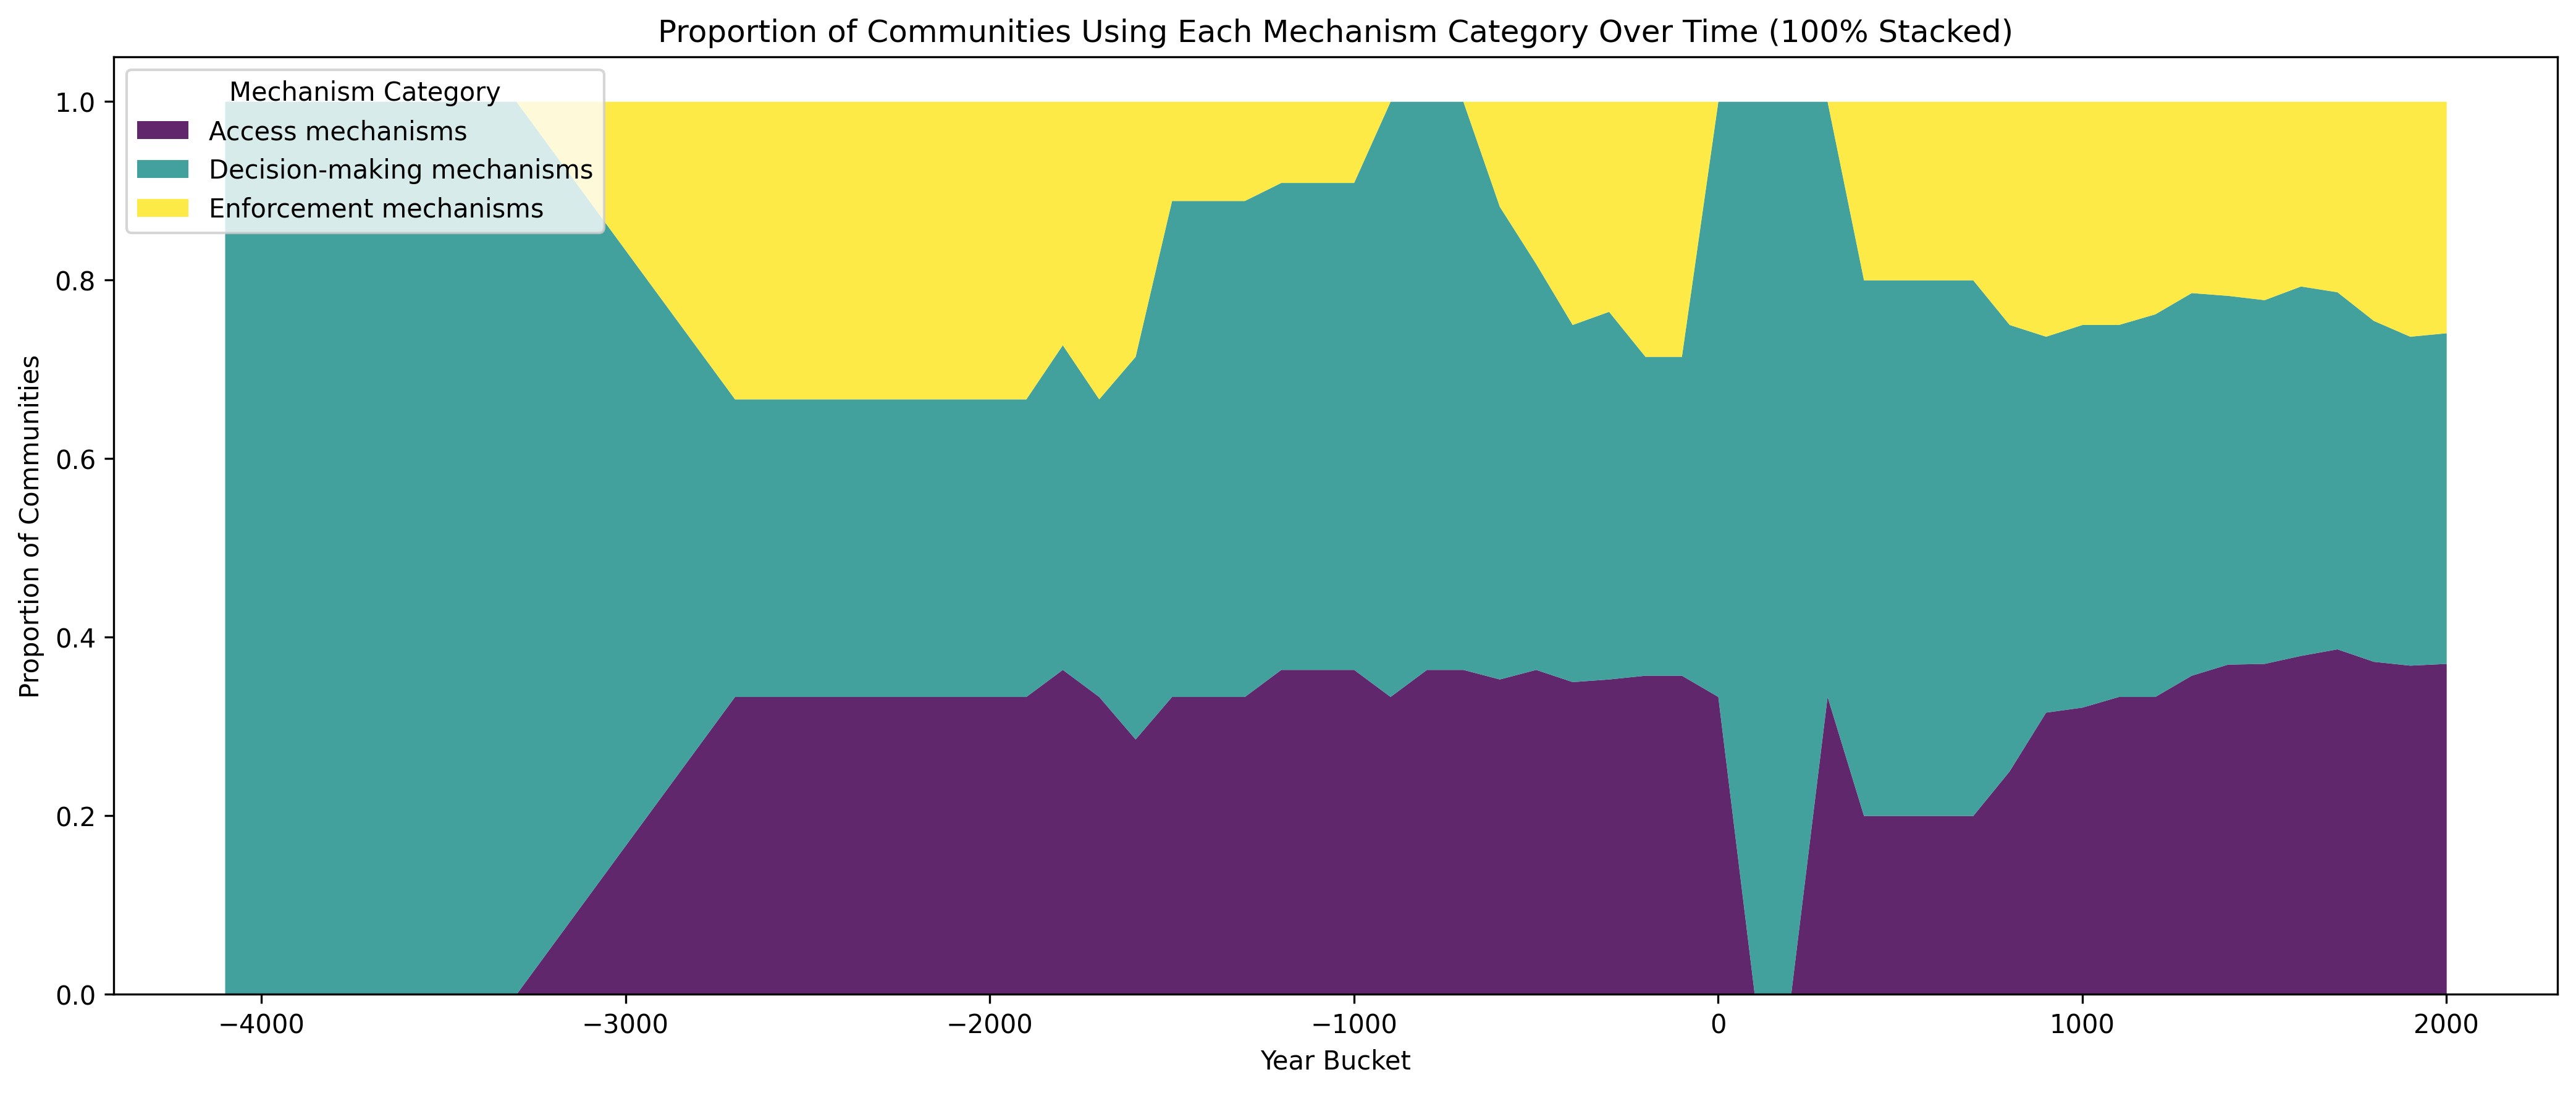

In [48]:
### 100% Stacked Area chart

# --- Step 3: Normalize for 100% stacked area chart ---
normalized_counts = raw_counts.div(raw_counts.sum(axis=1), axis=0)

# --- Step 4: Plot 100% stacked area chart ---
plt.figure(figsize=(14, 6))
normalized_counts.plot.area(
    stacked=True,
    cmap='viridis',
    alpha=0.85,
    linewidth=0,
    figsize=(14, 6)
)
plt.title('Proportion of Communities Using Each Mechanism Category Over Time (100% Stacked)')
plt.xlabel('Year Bucket')
plt.ylabel('Proportion of Communities')
plt.legend(title='Mechanism Category', loc='upper left')

plt.savefig('../' + DATA_VERSION + '-fig/fig-time/mechanisms_time_area_100pct.png', bbox_inches='tight')
plt.tight_layout()
plt.show()
